# UR5 – Cinemática Direta com Python + CoppeliaSim
### ENGA73 – Sistemas Robóticos | UFBA 2026.1



---
## 1. Imports e Parâmetros DH

Usa a convenção **DH Padrão** onde cada linha `i` descreve os parâmetros do link atual:  
`T = Rz(θ)·Tz(d)·Tx(a)·Rx(α)`

| Joint | a (m) | α | d (m) |
|---|---|---|---|
| 1 | 0 | +90° | 0.089159 |
| 2 | −0.425 | 0° | 0 |
| 3 | −0.39225 | 0° | 0 |
| 4 | 0 | +90° | 0.10915 |
| 5 | 0 | −90° | 0.09465 |
| 6 | 0 | 0° | 0.0823 |


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# Parâmetros DH – UR5
D1, D4, D5, D6 = 0.089159, 0.10915, 0.09465, 0.0823
A2, A3         = -0.425, -0.39225

# Tabela DH p
DH = [
    [ np.pi/2,    0,   D1],  # joint 1
    [ 0,         A2,    0],  # joint 2
    [ 0,         A3,    0],  # joint 3
    [ np.pi/2,    0,   D4],  # joint 4
    [-np.pi/2,    0,   D5],  # joint 5
    [ 0,          0,   D6],  # joint 6
]

print('Parâmetros DH:')
print(f"  {'i':<4} {'α (°)':>8} {'a (m)':>10} {'d (m)':>10}")
print('  ' + '-'*36)
for i,(alpha,a,d) in enumerate(DH):
    print(f'  {i+1:<4} {np.degrees(alpha):>8.1f} {a:>10.5f} {d:>10.5f}')


Parâmetros DH:
  i       α (°)      a (m)      d (m)
  ------------------------------------
  1        90.0    0.00000    0.08916
  2         0.0   -0.42500    0.00000
  3         0.0   -0.39225    0.00000
  4        90.0    0.00000    0.10915
  5       -90.0    0.00000    0.09465
  6         0.0    0.00000    0.08230


---
## 2. Funções de Cinemática Direta


In [29]:
def dh_transform(alpha, a, d, theta):
    """
    Transformação DH:
    T = Rz(θ) · Tz(d) · Tx(a) · Rx(α)
    """
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,  -st*ca,  st*sa,  a*ct],
        [st,   ct*ca, -ct*sa,  a*st],
        [ 0,    sa,    ca,     d   ],
        [ 0,    0,     0,      1   ]
    ])

def fk(thetas_deg):
    """FK completa. Retorna T (4x4) e cadeia de frames."""
    thetas = np.radians(thetas_deg)
    T = np.eye(4)
    chain = [T.copy()]
    for (alpha,a,d), theta in zip(DH, thetas):
        T = T @ dh_transform(alpha, a, d, theta)
        chain.append(T.copy())
    return T, chain

def rotation_to_rpy(R):
    """Extrai roll-pitch-yaw (ZYX) em graus de R (3x3)."""
    sy = np.sqrt(R[0,0]**2 + R[1,0]**2)
    if sy > 1e-6:
        roll  = np.degrees(np.
        arctan2( R[2,1], R[2,2]))
        pitch = np.degrees(np.arctan2(-R[2,0], sy))
        yaw   = np.degrees(np.arctan2( R[1,0], R[0,0]))
    else:
        roll  = np.degrees(np.arctan2(-R[1,2], R[1,1]))
        pitch = np.degrees(np.arctan2(-R[2,0], sy))
        yaw   = 0.0
    return np.array([roll, pitch, yaw])

def euler_xyz_to_matrix(rpy_deg):
    """Euler intrínseco XYZ (CoppeliaSim) → matriz R (3x3)."""
    rx, ry, rz = np.radians(rpy_deg)
    Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
    Ry = np.array([[np.cos(ry),0,np.sin(ry)],[0,1,0],[-np.sin(ry),0,np.cos(ry)]])
    Rz = np.array([[np.cos(rz),-np.sin(rz),0],[np.sin(rz),np.cos(rz),0],[0,0,1]])
    return Rx @ Ry @ Rz

def angular_error_deg(R_calc, R_gt):
    """Erro angular entre duas matrizes R — independente de convenção Euler."""
    R_err = R_calc.T @ R_gt
    cos_a = np.clip((np.trace(R_err) - 1) / 2, -1, 1)
    return np.degrees(np.arccos(cos_a))





---
## 3. Conexão com o CoppeliaSim
> ▶ Certifique-se que a simulação está em **Play** antes desta célula.


In [23]:
import sim, simConst

sim.simxFinish(-1)
clientID = sim.simxStart('127.0.0.1', 19999, True, True, 5000, 5)

if clientID > -1:
    print(f'Conectado! (clientID = {clientID})')
else:
    raise ConnectionError('Falhou — CoppeliaSim aberto e em Play?')


Conectado! (clientID = 0)


---
## 4. Handles dos Objetos


In [24]:
mode = sim.simx_opmode_blocking

joint_handles = []
for i in range(1, 7):
    ret, h = sim.simxGetObjectHandle(clientID, f'UR5_joint{i}', mode)
    print(f"  {'✅' if ret==0 else '❌'} UR5_joint{i}: handle={h}")
    joint_handles.append(h)

ret_b, base_handle = sim.simxGetObjectHandle(clientID, 'UR5', mode)
ret_e, ee_handle   = sim.simxGetObjectHandle(clientID, 'UR5_connection', mode)
#ret_e, ee_handle   = sim.simxGetObjectHandle(clientID, 'ROBOTIQ_85', mode) # Considerar Offset da garra

print(f"\n  {'✅' if ret_b==0 else '❌'} Base 'UR5'          : handle={base_handle}")
print(f"  {'✅' if ret_e==0 else '❌'} EE 'UR5_connection' : handle={ee_handle}")


  ✅ UR5_joint1: handle=31
  ✅ UR5_joint2: handle=34
  ✅ UR5_joint3: handle=37
  ✅ UR5_joint4: handle=40
  ✅ UR5_joint5: handle=43
  ✅ UR5_joint6: handle=45

  ✅ Base 'UR5'          : handle=29
  ✅ EE 'UR5_connection' : handle=48


---
## 5. Funções de Controle e Leitura


In [25]:
def set_joint_positions(thetas_deg):
    """Envia posições alvo para as 6 juntas (graus)."""
    for handle, angle in zip(joint_handles, thetas_deg):
        sim.simxSetJointTargetPosition(clientID, handle, np.radians(angle), sim.simx_opmode_oneshot)

def read_joint_positions():
    """Lê ângulos atuais das 6 juntas em graus."""
    angles = []
    for handle in joint_handles:
        _, angle = sim.simxGetJointPosition(clientID, handle, sim.simx_opmode_blocking)
        angles.append(np.degrees(angle))
    return np.array(angles)

def read_ee_pose():
    """
    Lê posição e orientação do EE relativa à BASE.
    Usa base_handle como referência — não o frame mundo (-1).
    """
    _, pos = sim.simxGetObjectPosition(clientID, ee_handle, base_handle, sim.simx_opmode_blocking)
    _, euler = sim.simxGetObjectOrientation(clientID, ee_handle, base_handle, sim.simx_opmode_blocking)
    return np.array(pos), np.degrees(euler)


---
## 6. Offset de Junta e Orientação

O zero físico das juntas na cena ≠ zero do modelo DH (robô deitado vs. em pé).  
`JOINT_OFFSET = [-90, -90, 0, -90, 0, 0]°` corrige essa diferença.  
`R_offset` corrige a rotação do frame do EE entre a cena e o modelo DH.


In [33]:
# Offset entre zero do CoppeliaSim (robô em pé) e zero do modelo DH (robô deitado)
JOINT_OFFSET = np.array([-90, -90, 0, -90, 0, 0], dtype=float)

def fk_com_offset(thetas_deg):
    """FK aplicando o offset de referência da cena."""
    return fk(np.array(thetas_deg, dtype=float) + JOINT_OFFSET)


# Offset fixo do gripper ROBOTIQ_85 (translação de 0.0146m em x6)
T_tool = np.array([
    [1, 0, 0, 0.0   ],
    [0, 1, 0, 0.0146],
    [0, 0, 1, 0.041 ],
    [0, 0, 0, 1     ]
])

def fk_com_gripper(thetas_deg):
    """FK incluindo o offset da garra ROBOTIQ_85."""
    T, chain = fk_com_offset(thetas_deg)
    T_with_gripper = T @ T_tool
    chain.append(T_with_gripper.copy())
    return T_with_gripper, chain

# Calcula R_offset usando Pose zero como referência
print('Calculando R_offset...')
set_joint_positions([0,0,0,0,0,0])
time.sleep(1.5)

gt_pos_ref, gt_euler_ref = read_ee_pose()
#T_ref, _ = fk_com_gripper([0,0,0,0,0,0])
T_ref, _ = fk_com_offset([0,0,0,0,0,0])

R_offset = T_ref[:3,:3].T @ euler_xyz_to_matrix(gt_euler_ref)

print(f'JOINT_OFFSET : {JOINT_OFFSET}')
print(f'R_offset     :\n{np.round(R_offset,3)}')
print(f'det(R_offset): {np.linalg.det(R_offset):.4f}')
print(f'\nPose zero — FK    : {np.round(T_ref[:3,3],4)}')
print(f'Pose zero — Simul.: {np.round(gt_pos_ref,4)}')
print(f'Erro inicial      : {np.linalg.norm(T_ref[:3,3]-gt_pos_ref)*1000:.2f} mm')


Calculando R_offset...
JOINT_OFFSET : [-90. -90.   0. -90.   0.   0.]
R_offset     :
[[-0.001  1.     0.   ]
 [-1.    -0.001 -0.   ]
 [-0.    -0.     1.   ]]
det(R_offset): 1.0000

Pose zero — FK    : [-0.1914  0.      1.0011]
Pose zero — Simul.: [-1.853e-01 -3.000e-04  9.865e-01]
Erro inicial      : 15.83 mm


---
## 7. Validação com 5 Poses

Para cada pose: envia ao simulador → lê ground truth → calcula FK → compara.


In [35]:
"""
test_poses = [
    [  0,   0,   0,   0,   0,   0],  # Pose 1 — zero
    [ 90,   0,   0,   0,   0,   0],  # Pose 2 — só junta 1
    [  0,  45,   0,   0,   0,   0],  # Pose 3 — só junta 2
    [ 45, -30,  60,   0,  45,   0],  # Pose 4 — arbitrária
    [-30,  60, -45,  30, -60,  90],  # Pose 5 — arbitrária
]
"""

test_poses = [
    [  0,   0,   0,   0,   0,    0], 
    [ 10,   15, -10, -15, -20,  10], 
    [ 80,   30,  45,  50,  20, 100], 
    [-100, -50, -30,   0,  100, -5],  
    [-10,   30,  35,  25,  15,  50],
    [150,   75,  20,  10,  -5,  15] 
]
results = []
print(f"{'='*58}")
print(f'  Validação FK ')
print(f"{'='*58}")

for i, pose in enumerate(test_poses):
    set_joint_positions(pose)
    time.sleep(1.5)

    gt_pos, gt_euler = read_ee_pose()

    #T, _ = fk_com_gripper(pose) # validar com a garra robotiq
    T, _ = fk_com_offset(pose) # validar sem garra robotiq
    calc_pos = T[:3, 3]
    R_calc   = T[:3,:3] @ R_offset
    R_gt     = euler_xyz_to_matrix(gt_euler)

    pos_err = np.linalg.norm(calc_pos - gt_pos) * 1000
    ang_err = angular_error_deg(R_calc, R_gt)

    results.append({'pose':pose,'calc_pos':calc_pos,'gt_pos':gt_pos,
                    'pos_err':pos_err,'ang_err':ang_err})

    print(f'\nPose {i+1}: θ = {pose}')
    print(f'  FK calc.  : {np.round(calc_pos,4)}')
    print(f'  Simulador : {np.round(gt_pos,4)}')
    print(f'  Erro pos  : {pos_err:.2f} mm')
    print(f'  Erro ang. : {ang_err:.2f}°')

print(f"\n{'='*58}")
print(f"  Erro médio posição  : {np.mean([r['pos_err'] for r in results]):.2f} mm")
print(f"  Erro médio angular  : {np.mean([r['ang_err'] for r in results]):.2f}°")
print(f"{'='*58}")


  Validação FK 

Pose 1: θ = [0, 0, 0, 0, 0, 0]
  FK calc.  : [-0.1914  0.      1.0011]
  Simulador : [-1.853e-01 -3.000e-04  9.865e-01]
  Erro pos  : 15.82 mm
  Erro ang. : 0.00°

Pose 2: θ = [10, 15, -10, -15, -20, 10]
  FK calc.  : [-0.2107  0.1207  0.9885]
  Simulador : [-0.2047  0.1192  0.9735]
  Erro pos  : 16.25 mm
  Erro ang. : 0.04°

Pose 3: θ = [80, 30, 45, 50, 20, 100]
  FK calc.  : [-0.707  -0.0647  0.5275]
  Simulador : [-0.7049 -0.0593  0.5104]
  Erro pos  : 18.06 mm
  Erro ang. : 0.06°

Pose 4: θ = [-100, -50, -30, 0, 100, -5]
  FK calc.  : [-0.7902  0.2357  0.3671]
  Simulador : [-0.7891  0.2376  0.3584]
  Erro pos  : 9.00 mm
  Erro ang. : 0.14°

Pose 5: θ = [-10, 30, 35, 25, 15, 50]
  FK calc.  : [-0.0707  0.6853  0.6443]
  Simulador : [-0.0649  0.6847  0.6274]
  Erro pos  : 17.87 mm
  Erro ang. : 0.07°

Pose 6: θ = [150, 75, 20, 10, -5, 15]
  FK calc.  : [-0.2799 -0.8671  0.1335]
  Simulador : [-0.2854 -0.8642  0.1186]
  Erro pos  : 16.17 mm
  Erro ang. : 0.09°

  Err

---
## 8. Gráficos de Validação


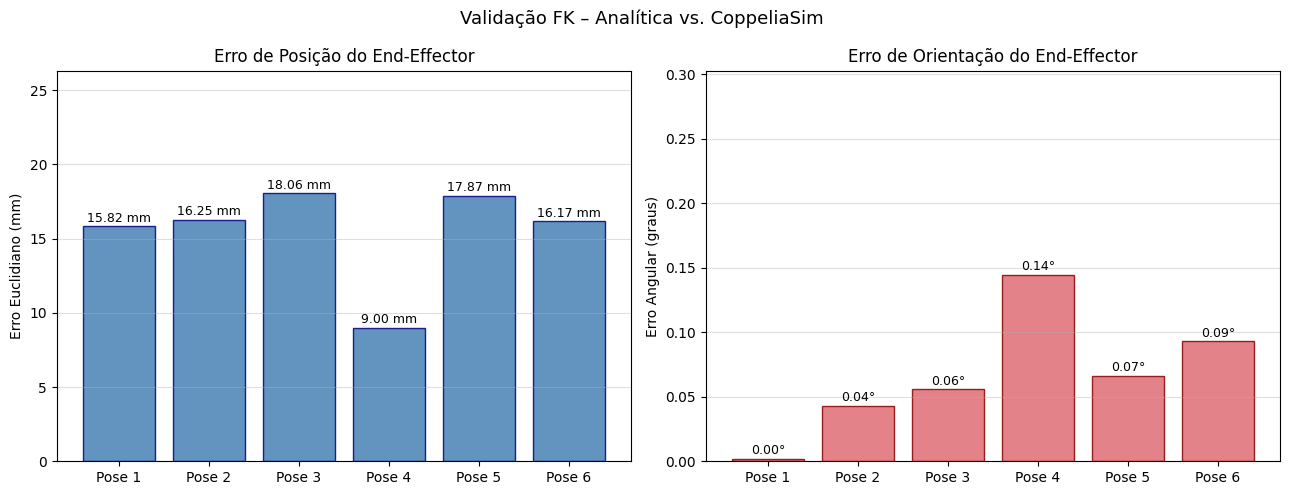

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validação FK – Analítica vs. CoppeliaSim ', fontsize=13)

labels = [f'Pose {i+1}' for i in range(len(results))]
x = np.arange(len(results))

# Erro de posição
pos_errors = [r['pos_err'] for r in results]
bars1 = ax1.bar(x, pos_errors, color='steelblue', edgecolor='navy', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Erro Euclidiano (mm)')
ax1.set_title('Erro de Posição do End-Effector')
ax1.set_ylim(0, max(pos_errors)*1.4 + 1)
for bar,val in zip(bars1, pos_errors):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f} mm', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# Erro de orientação
ang_errors = [r['ang_err'] for r in results]
bars2 = ax2.bar(x, ang_errors, color='#e06c75', edgecolor='darkred', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('Erro Angular (graus)')
ax2.set_title('Erro de Orientação do End-Effector')
ax2.set_ylim(0, max(ang_errors)*1.4 + 0.1)
for bar,val in zip(bars2, ang_errors):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f'{val:.2f}°', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
#plt.savefig('validacao_fk.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Visualização 3D da Cadeia Cinemática


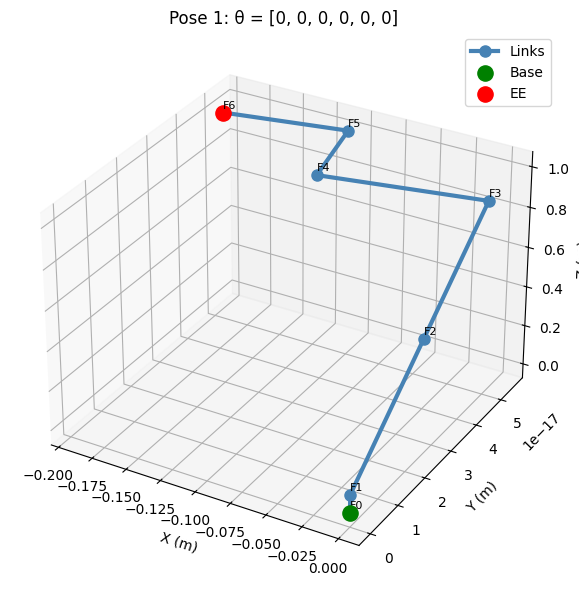

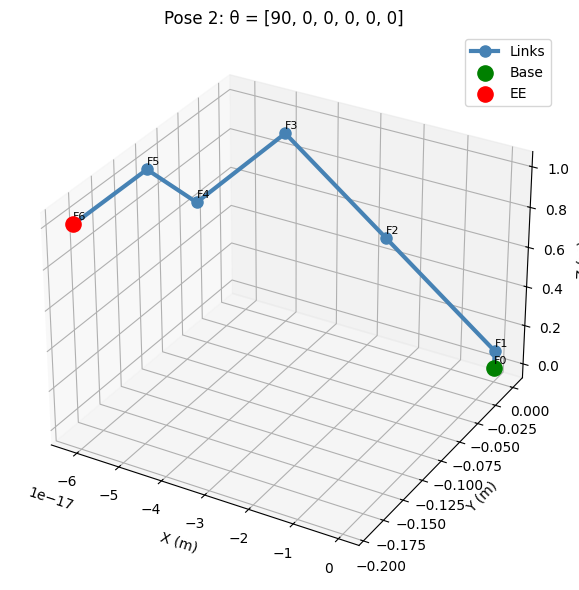

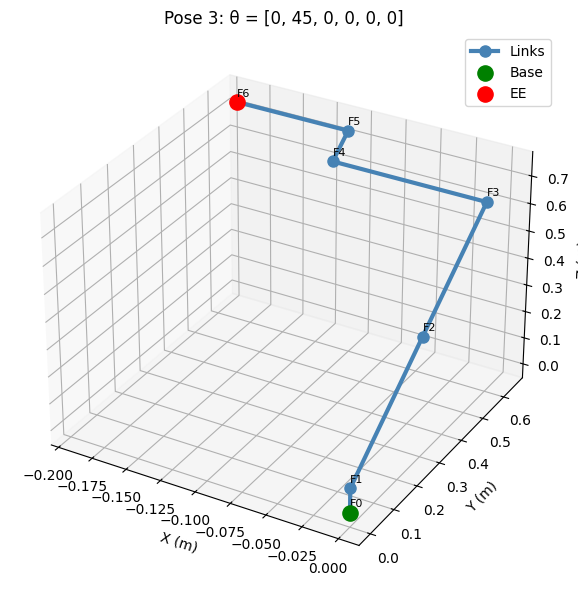

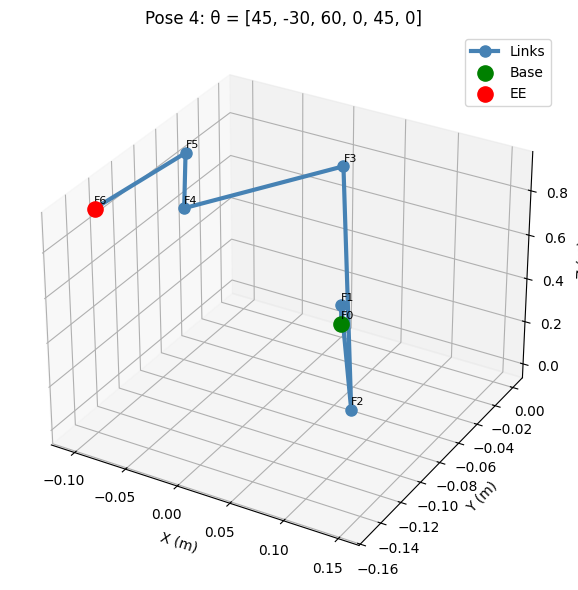

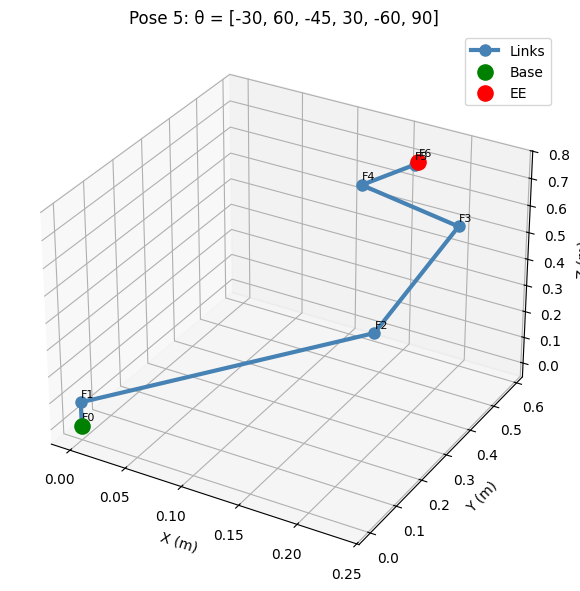

In [ ]:
def plot_robot(thetas_deg, title='UR5'):
    """Plota a cadeia cinemática 3D com offset."""
    _, chain = fk_com_offset(thetas_deg)
    pos = np.array([T[:3,3] for T in chain])

    fig = plt.figure(figsize=(7,6))
    ax  = fig.add_subplot(111, projection='3d')
    ax.plot(pos[:,0], pos[:,1], pos[:,2],'o-', color='steelblue', lw=3, ms=8, label='Links')
    ax.scatter(*pos[0],  color='green', s=120, zorder=5, label='Base')
    ax.scatter(*pos[-1], color='red',   s=120, zorder=5, label='EE')
    for i,p in enumerate(pos):
        ax.text(p[0], p[1], p[2]+0.02, f'F{i}', fontsize=8)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

for i, pose in enumerate(test_poses):
    plot_robot(pose, title=f'Pose {i+1}: θ = {pose}')


---
## 10. Desconectar


In [7]:
sim.simxAddStatusbarMessage(clientID, 'Python desconectado', sim.simx_opmode_oneshot)
time.sleep(0.1)
sim.simxFinish(-1)
print('Desconectado ✅')


Desconectado ✅
